In [1]:
import os
import sys

project_root = os.path.abspath("../../")
print(project_root)
if project_root not in sys.path:
    sys.path.append(project_root)

/home2/a/amiber/projects/phme26


In [2]:
from core.utils import load_best_params_lookup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

/nfs/home/amiber/conda_envs/phme26_conda_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def transform_results_to_df(output_data: dict) -> pd.DataFrame:
    """
    Flattens the nested training results into a clean Pandas DataFrame.
    """
    rows = []
    training_params = output_data.get("training_best_params", {})

    for dataset, windows in training_params.items():
        for win_id, details in windows.items():
            rows.append(
                {
                    "dataset": dataset,
                    "win_len": details.get("window_len"),
                    "best_lr": details.get("lr"),
                    "best_batch_size": details.get("batch_size"),
                    "best_loss_value": details.get("best_val_loss"),
                }
            )

    # Create the DataFrame
    df = pd.DataFrame(rows)

    # Optional: Sort by dataset and window length for better readability
    if not df.empty:
        df = df.sort_values(by=["dataset", "win_len"]).reset_index(drop=True)

    return df


In [4]:
def get_best_per_dataset(df):
    # 1. Group by dataset
    # 2. Find the index (idxmin) of the row with the minimum loss for each group
    # 3. Use .loc to pull the full rows at those indices
    best_rows = df.loc[df.groupby("dataset")["best_loss_value"].idxmin()]

    return best_rows.sort_values("dataset")


In [5]:
def plot_best_loss(dataframe, routine):
    """
    Generates a line plot of best_loss_value vs win_len grouped by dataset.

    Args:
        dataframe (pd.DataFrame): Dataframe containing 'win_len',
                                 'best_loss_value', and 'dataset' columns.
    """
    # Create the figure and axis
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot using seaborn
    sns.lineplot(
        data=dataframe,
        x="win_len",
        y="best_loss_value",
        hue="dataset",
        marker="o",
        ax=ax,
    )

    # Set logarithmic scale for the Y-axis
    ax.set_yscale("log")

    # Labeling
    ax.set_title(f"Best Loss Value vs Window Length - {routine}")
    ax.set_xlabel("Window Length (win_len)")
    ax.set_ylabel("Best Loss Value (Log Scale)")

    # Optional: ensure layout is tight
    plt.tight_layout()

    return fig, ax


In [6]:
diction_raw = load_best_params_lookup("best_params_raw_scaled_sequenced_lstm.jsonl")
diction_raw_env = load_best_params_lookup("best_params_raw_env_scaled_sequenced_lstm.jsonl")

In [7]:
df_raw = transform_results_to_df(diction_raw["Raw -> Scaled -> Sequenced -> LSTM"])
df_raw

,dataset,win_len,best_lr,best_batch_size,best_loss_value
0,cwru,10,0.00050,8,5.724980e-02
1,cwru,20,0.00050,8,3.645139e-02
2,cwru,40,0.00050,8,1.660180e-02
3,cwru,80,0.00050,8,2.332109e-02
4,cwru,100,0.00050,32,9.128083e-02
5,cwru,200,0.00050,8,2.005753e-01
6,cwru,400,0.00005,128,3.158321e-01
7,cwru,800,0.00001,16,4.607934e-01
8,cwru,1200,0.00005,128,4.958012e-01
9,cwru,2400,0.00005,64,6.058421e-01


In [8]:
winners_df_raw = get_best_per_dataset(df_raw)
winners_df_raw

,dataset,win_len,best_lr,best_batch_size,best_loss_value
2,cwru,40,0.0005,8,1.660180e-02
13,kaist,80,0.0005,8,2.032807e-08
22,mfpt,40,0.0005,8,3.457347e-02


In [9]:
df_raw_env = transform_results_to_df(diction_raw_env["Raw -> Env -> Scaled -> Sequenced -> LSTM"])
df_raw_env

,dataset,win_len,best_lr,best_batch_size,best_loss_value
0,cwru,10,0.00050,32,0.012189
1,cwru,20,0.00050,8,0.005973
2,cwru,40,0.00050,8,0.018005
3,cwru,80,0.00050,8,0.056075
4,cwru,100,0.00050,8,0.091173
5,cwru,200,0.00001,8,0.160904
6,cwru,400,0.00050,128,0.200625
7,cwru,800,0.00005,64,0.274992
8,cwru,1200,0.00010,64,0.344681
9,cwru,2400,0.00001,16,0.554210


In [10]:
winners_df_raw_env = get_best_per_dataset(df_raw_env)
winners_df_raw_env

,dataset,win_len,best_lr,best_batch_size,best_loss_value
1,cwru,20,0.00050,8,0.005973
14,kaist,100,0.00050,8,0.000001
28,mfpt,1200,0.00005,8,0.049975


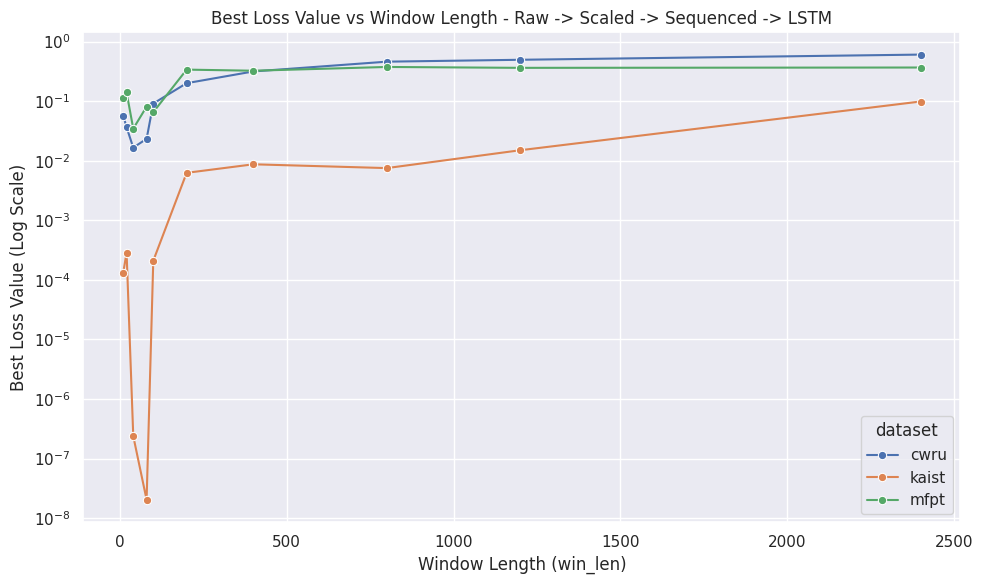

In [13]:
fig, _ = plot_best_loss(df_raw, "Raw -> Scaled -> Sequenced -> LSTM")
plt.savefig("raw_lstm_win_length.png", bbox_inches=None, dpi=500)
plt.show()

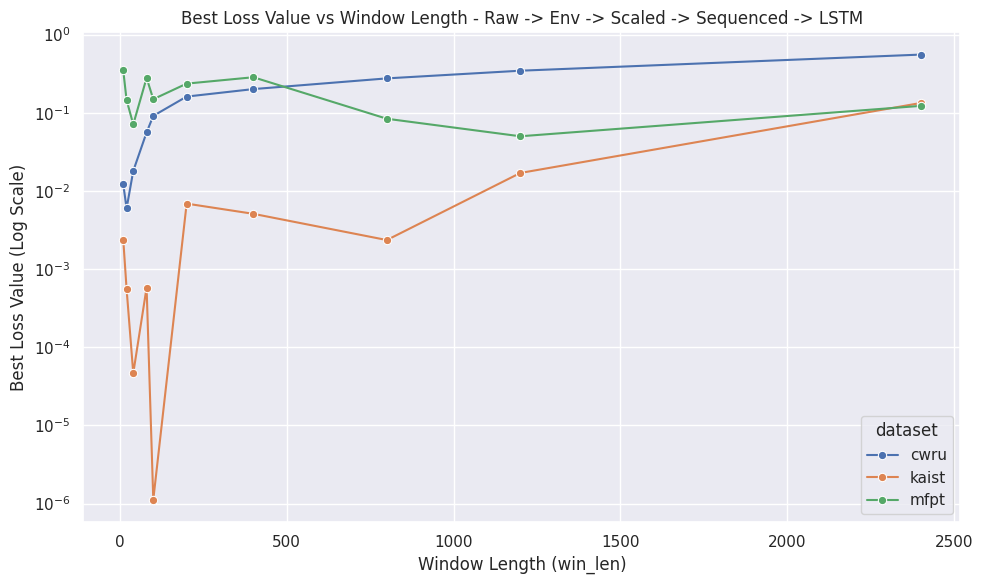

In [14]:
fig, _ = plot_best_loss(df_raw_env, "Raw -> Env -> Scaled -> Sequenced -> LSTM")
plt.savefig("env_lstm_win_length.png", bbox_inches=None, dpi=500)
plt.show()
